In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle (3).json


{'kaggle (3).json': b'{"username":"takiallahbenali","key":"c88bfc7e84ef8c3d7632ce9e7e98ef5a"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:

!kaggle datasets download iarunava/cell-images-for-detecting-malaria

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
cell-images-for-detecting-malaria.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
from zipfile import ZipFile
dataset='/content/cell-images-for-detecting-malaria.zip'
with ZipFile(dataset,'r') as zip_f:
  zip_f.extractall()
  print('the dataset is extracted')


the dataset is extracted


In [ ]:
!ls


 cell_images				'kaggle (2).json'   sample_data
 cell-images-for-detecting-malaria.zip	'kaggle (3).json'
'kaggle (1).json'			 kaggle.json


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.utils import shuffle
from torch.utils.data import TensorDataset ,DataLoader

In [ ]:
infected= os.listdir("/content/cell_images/Parasitized")
noninfected=os.listdir("/content/cell_images/Uninfected")
print(infected[0:5])
print(noninfected[-5:])

['C182P143NThinF_IMG_20151201_171950_cell_158.png', 'C179P140ThinF_IMG_20151127_153852_cell_153.png', 'C181P142ThinF_IMG_20151127_155722_cell_185.png', 'C140P101ThinF_IMG_20151005_205406_cell_173.png', 'C110P71ThinF_IMG_20150930_105319_cell_186.png']
['C204ThinF_IMG_20151029_112502_cell_161.png', 'C233ThinF_IMG_20151112_160059_cell_129.png', 'C223ThinF_IMG_20151112_104708_cell_18.png', 'C63P24N_ThinF_IMG_20150818_142948_cell_162.png', 'C135P96ThinF_IMG_20151005_124204_cell_121.png']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
infected_label=[1]*len(infected)
noninfected_label=[0]*len(noninfected)
all_lab=infected_label+noninfected_label


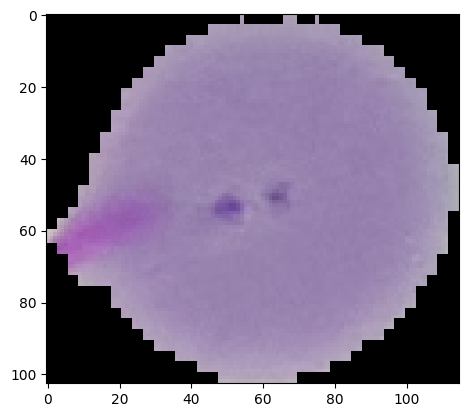

In [ ]:
img=mpimg.imread("/content/cell_images/Parasitized/C173P134NThinF_IMG_20151130_115339_cell_260.png")
imgplot=plt.imshow(img)
plt.show()

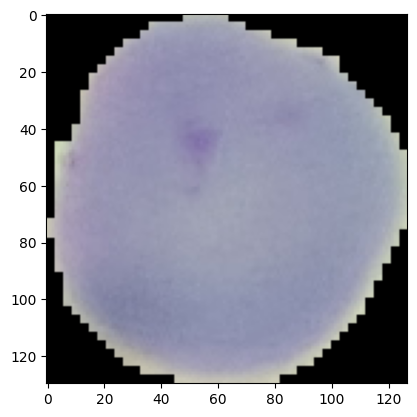

In [ ]:
img=mpimg.imread("/content/cell_images/Uninfected/C149P110ThinF_IMG_20151115_114729_cell_185.png")
imgplot=plt.imshow(img)
plt.show()

In [ ]:
x_train , x_test  = train_test_split(infected ,test_size=0.3 , random_state=42)
y_train , y_test = train_test_split(noninfected ,test_size=0.3 , random_state=42)


In [ ]:
train_transforms=transforms.Compose([transforms.RandomHorizontalFlip(),transforms.RandomRotation(45),transforms.ToTensor(),transforms.Resize((64,64)),])
infpath=[os.path.join("/content/cell_images/Parasitized",i) for i in x_train if i.lower().endswith((".jpg", ".jpeg", ".png"))]
ninfpath=[os.path.join("/content/cell_images/Uninfected",j) for j in y_train if j.lower().endswith((".jpg", ".jpeg", ".png"))]
infaug=[]
ninfaug=[]

for i in infpath :
  inimg=train_transforms(Image.open(i))
  infaug.append(inimg)
for j in ninfpath :
  ninfimg=train_transforms(Image.open(j))
  ninfaug.append(ninfimg)

npinfimg=[np.array(i) for i in infaug]
npinfaug=[np.array(i) for i in ninfaug]

inlab=[1]*len(infaug)
ninflab=[0]*len(ninfaug)
all_lab=inlab+ninflab
allimg=infaug+ninfaug
x=(np.array(allimg))
y=np.array(all_lab)
x,y=shuffle(x,y,random_state=42)










In [ ]:
class Mal(nn.Module):
  def __init__(self,num_classes):
    super().__init__()
    self.featureextractor=nn.Sequential(
        nn.Conv2d(3,32, kernel_size=4 , padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),
        nn.Conv2d(32,64,kernel_size=4,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),
        nn.Flatten(),
        nn.Linear(14400,128),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Dropout(0.4),
        )
    self.classifier=nn.Sequential(
      nn.Linear(64,num_classes)
  )
  def forward(self,p):
    p=self.featureextractor(p)
    p=self.classifier(p)
    return p

In [ ]:
x=torch.tensor(x,dtype=torch.float32).to(device)
y=torch.tensor(y,dtype=torch.int64).to(device)
data=TensorDataset(x,y)
train=DataLoader(data, batch_size=32 , shuffle=True)


In [ ]:
model=Mal(2).to(device)
cri=nn.CrossEntropyLoss()
opti=optim.Adam(model.parameters(),lr=0.0002)
for epoch in range(18):
  model.train()
  running_loss=0
  correct_predictions=0
  total_samples=0
  for dt , label in train:
    dt = dt.to(device)
    label = label.to(device)
    opti.zero_grad()
    out=model(dt)
    loss=cri(out,label)
    loss.backward()
    opti.step()
    running_loss += loss.item() * dt.size(0)

    with torch.no_grad():
      predicted = out.argmax(dim=1)
      correct_predictions += (predicted == label).sum().item()
      total_samples += label.size(0)


  if (epoch + 1) % 4 == 0:
      avg_loss = running_loss / total_samples
      avg_acc = correct_predictions / total_samples

      print(f"Epoch [{epoch+1}/{20}], Loss: {avg_loss:.4f}, Accuracy: {avg_acc * 100:.2f}%")

Epoch [4/20], Loss: 0.1831, Accuracy: 93.81%
Epoch [8/20], Loss: 0.1159, Accuracy: 96.04%
Epoch [12/20], Loss: 0.0751, Accuracy: 97.60%
Epoch [16/20], Loss: 0.0390, Accuracy: 98.86%


In [ ]:
test_transforms=transforms.Compose([transforms.Resize((64,64)),transforms.ToTensor(),])


In [ ]:
inftest=[os.path.join("/content/cell_images/Parasitized",i) for i in x_test if i.lower().endswith((".jpg", ".jpeg", ".png"))]
ntest=[os.path.join("/content/cell_images/Uninfected",j) for j in y_test if j.lower().endswith((".jpg", ".jpeg", ".png"))]
for i in infpath :
  inimg=test_transforms(Image.open(i))
  infaug.append(inimg)
for j in ninfpath :
  ninfimg=test_transforms(Image.open(j))
  ninfaug.append(ninfimg)

npinfimg=[np.array(i) for i in infaug]
npinfaug=[np.array(i) for i in ninfaug]

inlab=[1]*len(infaug)
ninflab=[0]*len(ninfaug)
all_lab=inlab+ninflab
allimg=infaug+ninfaug
x=(np.array(allimg))
y=np.array(all_lab)


In [ ]:
correct_predictions=0
total_samples=0


In [ ]:
model.eval()
with torch.no_grad():
  for dt , label in zip(x,y):
    dt = torch.tensor(dt, dtype=torch.float32).to(device)
    label = torch.tensor(label, dtype=torch.long).to(device)

    dt = dt.unsqueeze(0)
    label = label.unsqueeze(0)
    out=model(dt)
    predicted = out.argmax(dim=1)
    correct_predictions += (predicted == label).sum().item()
    total_samples += label.size(0)
  avg_acc = correct_predictions / total_samples

  print(f" Accuracy: {avg_acc}")




 Accuracy: 0.9779160186625194%
